# NSE Stocks Data
---
## Uso de DataFrames
Los DataFrames son el tipo de onjetos principales de Pandas. Son una representación de una tabla. Se pueden acceder a las filas y a las columnas. Cada una de las columnas se considera una Serie.

## Proceso para analizar un archivo
1. Cargra el archivo en un DataFrame
2. Hacer una revision de los tipos de datos del archivo.
3. Revisar si existen daros nulos y datos duplicados en el archivo.
4. Eliminar inconsistencias.
5. Llevar a cabo el análisis apoyados de gráfica.

## Tomar en consideración:
- Elegir un archivo que contenga datos numéricos y no numéricos.
- Crear un archivo como este que contenga la descripción de su proceso de ánalisis.
- Preparar una presentación para el día de entrega (viernes).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("FINAL_FROM_DF.CSV")

In [3]:
# df.head() -> Primeras 5 filas de su archivo
# df.head(n) -> Primeras n filas de archivo
df.head()

,SYMBOL,SERIES,OPEN,HIGH,LOW,CLOSE,LAST,PREVCLOSE,TOTTRDQTY,TOTTRDVAL,TIMESTAMP,TOTALTRADES,ISIN
0,20MICRONS,EQ,37.80,37.80,36.15,36.85,37.40,37.05,27130,994657.90,2017-06-28,202,INE144J01027
1,3IINFOTECH,EQ,4.10,4.85,4.00,4.55,4.65,4.05,20157058,92148517.65,2017-06-28,7353,INE748C01020
2,3MINDIA,EQ,13425.15,13469.55,12920.00,13266.70,13300.00,13460.55,2290,30304923.35,2017-06-28,748,INE470A01017
3,63MOONS,EQ,61.00,61.90,60.35,61.00,61.10,60.65,27701,1689421.00,2017-06-28,437,INE111B01023
4,8KMILES,EQ,546.10,548.00,535.00,537.45,535.20,547.45,79722,43208620.05,2017-06-28,1866,INE650K01021


In [ ]:
df.break()

AttributeError: 'DataFrame' object has no attribute 'breack'

In [6]:
df.columns

Index(['SYMBOL', 'SERIES', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'LAST', 'PREVCLOSE',
       'TOTTRDQTY', 'TOTTRDVAL', 'TIMESTAMP', 'TOTALTRADES', 'ISIN'],
      dtype='object')

In [7]:
# Selección
df["TOTALTRADES"]

0          202
1         7353
2          748
3          437
4         1866
          ... 
846399      14
846400    2218
846401    2001
846402    1401
846403     845
Name: TOTALTRADES, Length: 846404, dtype: int64

In [8]:
df[['']]

KeyError: "None of [Index([''], dtype='object')] are in the [columns]"

In [9]:
# Medidas de tendencia central
print(f"Promedio: {df['TOTALTRADES'].mean()}")
print(f"Mediana: {df['TOTALTRADES'].median()}")
print(f"Moda: {df['TOTALTRADES'].mode()}")
# Medidas de dispersión
print(f"Desviación estándar: {df['TOTALTRADES'].std()}")
print(f"Varianza: {df['TOTALTRADES'].var()}")
# Medidas de posicionamiento
print(f"Mínimo: {df['TOTALTRADES'].min()}")
print(f"Q1: {df['TOTALTRADES'].quantile(0.25)}")
print(f"Q2: {df['TOTALTRADES'].quantile(0.50)}")
print(f"Q3: {df['TOTALTRADES'].quantile(0.75)}")
print(f"Máximo: {df['TOTALTRADES'].max()}")

Promedio: 5013.823219171932
Mediana: 600.0
Moda: 0    1
Name: TOTALTRADES, dtype: int64
Desviación estándar: 14901.118242887625
Varianza: 222043324.8885184
Mínimo: 1
Q1: 84.0
Q2: 600.0
Q3: 3028.0
Máximo: 1192900


<Axes: >

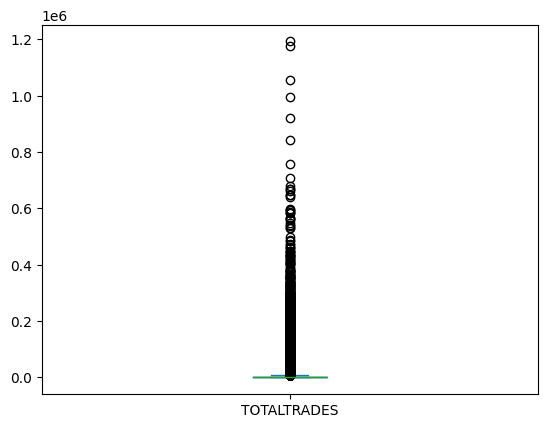

In [10]:
# Cajas y bogotes (box & whiskers) -> Gráficas de cajas (boxplots)
df["TOTALTRADES"].plot.box()

In [11]:
df["TOTALTRADES"].dtype

dtype('int64')

In [12]:
columnas_númericas = []
columnas_no_númericas = []
for col in df.columns:
    if df[col].dtype == "object":
        columnas_no_númericas.append(col)
    else:
        columnas_númericas.append(col)
print(f"Columnas numéricas: {columnas_númericas}")
print (f"Columnas no numéricas: {columnas_no_númericas}")

Columnas numéricas: ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'LAST', 'PREVCLOSE', 'TOTTRDQTY', 'TOTTRDVAL', 'TOTALTRADES']
Columnas no numéricas: ['SYMBOL', 'SERIES', 'TIMESTAMP', 'ISIN']


In [13]:
# Si encuentran una columna que se detectó como texto (object) y debería ser numérica
df["TIMESTAMP"] = pd.to_numeric(df["TIMESTAMP"].str.replace("-",""))

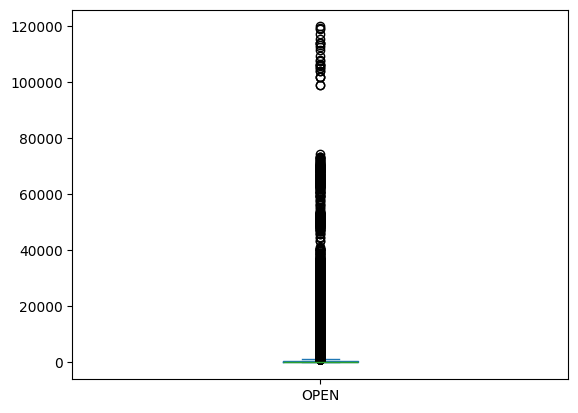

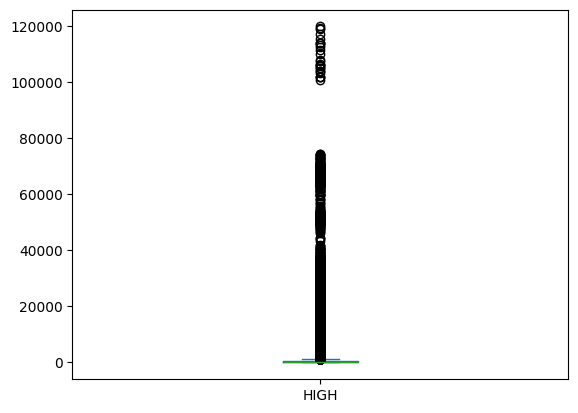

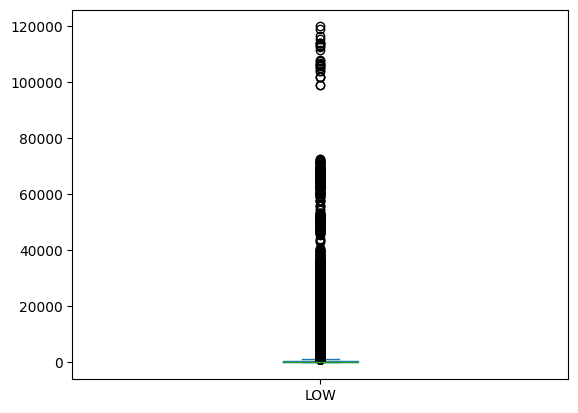

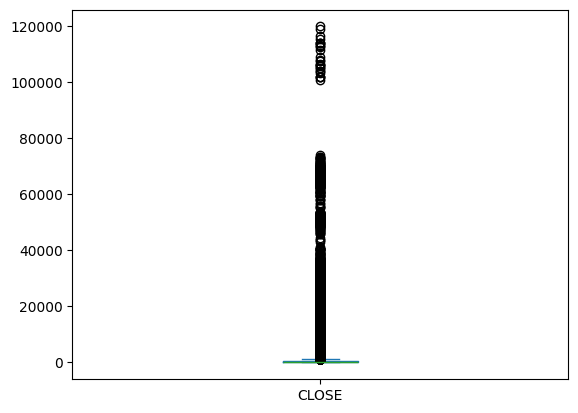

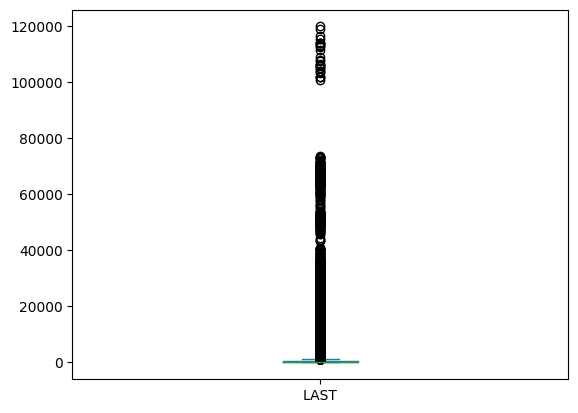

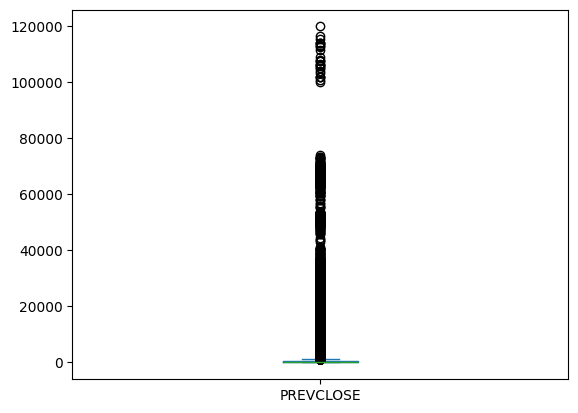

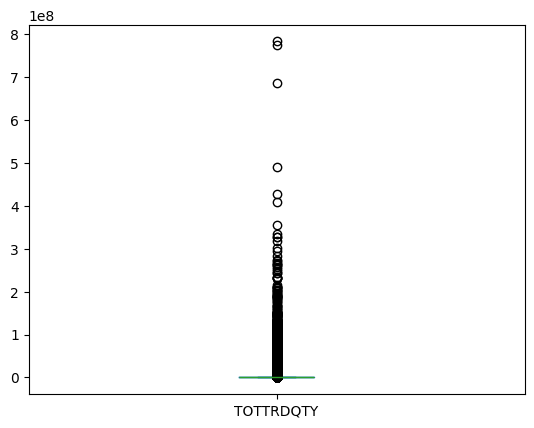

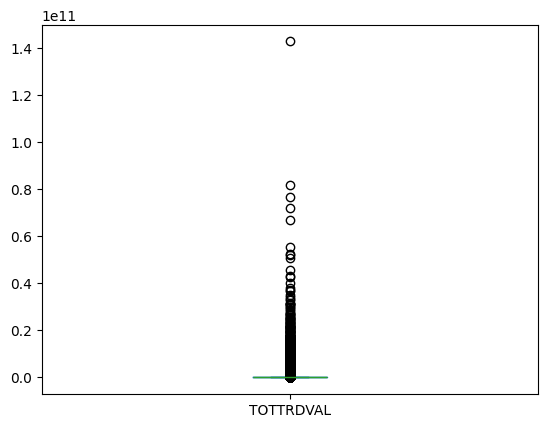

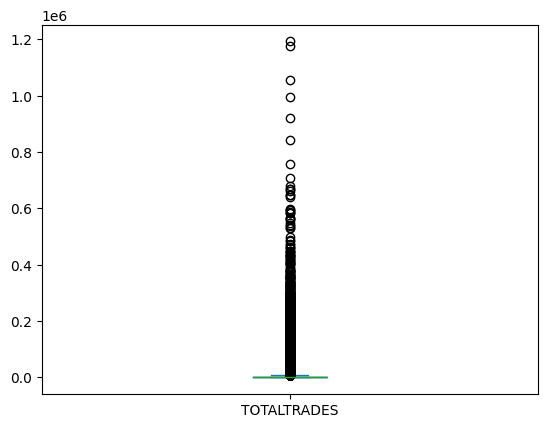

In [16]:
for col in columnas_númericas:
    df[col].plot.box()
    plt.show()

ModuleNotFoundError: No module named 'scipy'

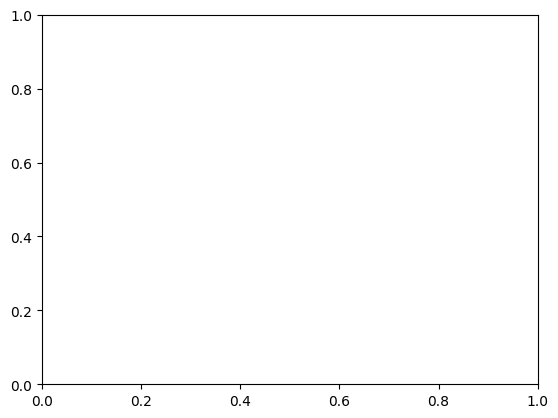

In [17]:
for col in columnas_númericas:
    df[col].plot.kde()
    plt.show()

In [ ]:
df.plot.bar(x="SERIES", y = "TOTALTRADES")

KeyboardInterrupt: 

In [ ]:
df.groupby("SERIES")["TOTALTRADES"].mean() 

In [ ]:
df["SERIES"].value_counts().nlargest(5).plot.pie(autopct = "")